In [1]:
import numpy as np
import xarray as xr
import cf_xarray as cfxr
import cf_xarray.units
import pint_xarray
import pint
from pint import application_registry as ureg
import matplotlib.pyplot as plt
import intake

from os import environ
environ["PYTHONWARNINGS"] = "ignore"
import glob
import os

import warnings

warnings.filterwarnings("ignore",message="The specified chunks separate the stored chunks.*",
    category=UserWarning)

CATALOG = "/leonardo/home/userexternal/ntilinin/access-om2-catalog/AccessOm2RYF_SPEEDY100YR.json"
CATALOG1 = "/leonardo/home/userexternal/ntilinin/access-om2-catalog/AccessOm2RYF_JRA55100YR.json"

catalog_speedy = intake.open_esm_datastore(
    CATALOG,
    columns_with_iterables=["variable","variable_long_name","variable_standard_name",
        "variable_cell_methods","variable_units"])

catalog_jra = intake.open_esm_datastore(
    CATALOG1,
    columns_with_iterables=["variable","variable_long_name","variable_standard_name",
        "variable_cell_methods","variable_units"])


In [2]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

cluster = SLURMCluster(memory="50GB",
    processes=1,cores=1,
    walltime="02:00:00",queue="dcgp_usr_prod",
    account="ICT26_ESP",interface="ib0",
    job_script_prologue=["export OMP_NUM_THREADS=1","export MKL_NUM_THREADS=1",
        "export NUMBA_NUM_THREADS=1"],
    job_extra_directives=[
        "--nodes=1",
        "--ntasks-per-node=1",
        "--hint=nomultithread",
    ],log_directory="logs/")

cluster.scale(1)

client = Client(cluster)
client

/leonardo/home/userexternal/ntilinin/.conda/envs/ocean/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38271 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://10.128.0.5:38271/status,
Dashboard: http://10.128.0.5:38271/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.128.0.5:38273,Workers: 0
Dashboard: http://10.128.0.5:38271/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [3]:
!squeue -u ntilinin

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
          57806986 dcgp_usr_ dask-wor ntilinin PD       0:00      1 (Priority)
          57800519 dcgp_usr_     wrap ntilinin  R    1:07:36      6 lrdn[4483,4492,4497,4513-4514,4517]
          57798032 dcgp_usr_     wrap ntilinin  R    1:42:59      6 lrdn[4265-4266,4268-4269,4271-4272]
          57805666 dcgp_usr_ dask-wor ntilinin  R      15:38      1 lrdn3998
          57805667 dcgp_usr_ dask-wor ntilinin  R      15:38      1 lrdn3998


In [5]:
start_year, end_year = 1900, 1940
time_slice = slice(f"{start_year}-01-01", f"{end_year}-12-31")

adv = catalog_speedy.search(variable="temp_yflux_adv_int_z", frequency="1mon").to_dask()["temp_yflux_adv_int_z"].sel(time=time_slice)
gm = catalog_speedy.search(variable="temp_yflux_gm_int_z", frequency="1mon").to_dask()["temp_yflux_gm_int_z"].sel(time=time_slice)
ndiff = catalog_speedy.search(variable="temp_yflux_ndiffuse_int_z", frequency="1mon").to_dask()["temp_yflux_ndiffuse_int_z"].sel(time=time_slice)
submeso = catalog_speedy.search(variable="temp_yflux_submeso_int_z", frequency="1mon").to_dask()["temp_yflux_submeso_int_z"].sel(time=time_slice)

In [6]:
adv_mht = (adv.sum("xt_ocean").mean("time")/1e15).compute()
gm_mht = (gm.sum("xt_ocean").mean("time") / 1e15).compute()
ndiff_mht = (ndiff.sum("xt_ocean").mean("time") / 1e15).compute()
submeso_mht = (submeso.sum("xt_ocean").mean("time") / 1e15).compute()
total_mht = (adv_mht + gm_mht + ndiff_mht + submeso_mht).compute()

In [7]:
adv_jra = catalog_jra.search(variable="temp_yflux_adv_int_z", frequency="1mon").to_dask()["temp_yflux_adv_int_z"].sel(time=time_slice)
gm_jra = catalog_jra.search(variable="temp_yflux_gm_int_z", frequency="1mon").to_dask()["temp_yflux_gm_int_z"].sel(time=time_slice)
ndiff_jra = catalog_jra.search(variable="temp_yflux_ndiffuse_int_z", frequency="1mon").to_dask()["temp_yflux_ndiffuse_int_z"].sel(time=time_slice)
submeso_jra = catalog_jra.search(variable="temp_yflux_submeso_int_z", frequency="1mon").to_dask()["temp_yflux_submeso_int_z"].sel(time=time_slice)

In [8]:
total_mht_jra = (adv_jra + gm_jra + ndiff_jra + submeso_jra).compute()

ValueError: x and y must have same first dimension, but have shapes (300,) and (480, 300, 360)

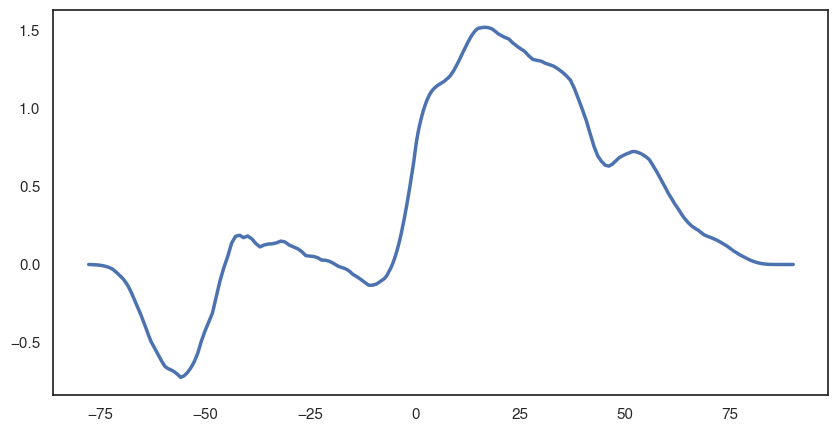

In [9]:
import seaborn as sns
import matplotlib.ticker as ticker
sns.set_theme(style="white")
plt.rcParams.update({"font.family": "Nimbus Sans"})

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(total_mht.yu_ocean, total_mht, linewidth=2.5, label="SPEEDY RYF 90-91")
ax.plot(total_mht_jra.yu_ocean, total_mht_jra, linewidth=2.5, label="JRA55-do RYF 90-01")
ax.axhline(0, linewidth=1, alpha=0.6)

ax.set_xlim(-80, 65)
ax.set_title(f"ACCESS-OM2 (Model Years {start_year}–{end_year}): Global Ocean Meridional Heat Transport", fontsize=14, pad=10, fontweight="bold")
#ax.set_title("ACCESS-0M2 1-8 Model Year Global Ocean Meridional Heat Transport", fontsize=14, pad=10, fontweight="bold")
ax.set_ylabel("Meridional heat transport [PW]", fontsize=13, labelpad=10)
ax.set_xlabel("Latitude [°]", fontsize=13, labelpad=10)
ax.tick_params(axis="both", labelsize=12, width=1.2)

ax.spines["top"].set_visible(0.5)
ax.spines["right"].set_visible(0.5)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

ax.legend(frameon=False, fontsize=12)
fig.tight_layout()
plt.show()

NameError: name 'jra_total_mht' is not defined

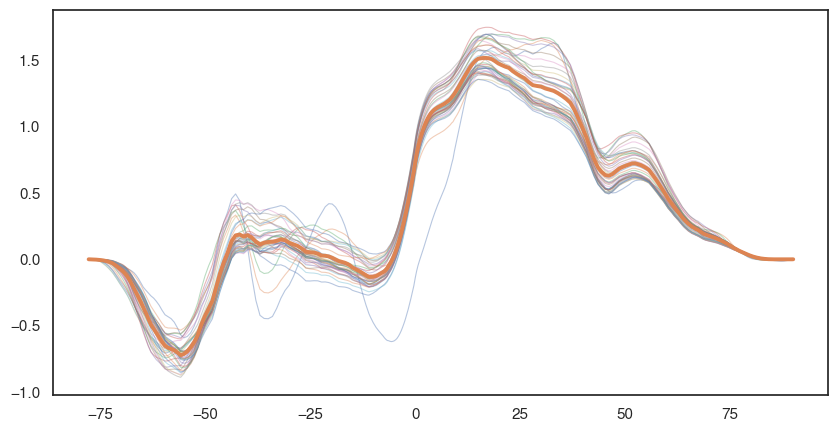

In [10]:
adv_ann = (adv.sum("xt_ocean").groupby("time.year").mean("time") / 1e15).compute()
gm_ann = (gm.sum("xt_ocean").groupby("time.year").mean("time") / 1e15).compute()
ndiff_ann = (ndiff.sum("xt_ocean").groupby("time.year").mean("time") / 1e15).compute()
submeso_ann = (submeso.sum("xt_ocean").groupby("time.year").mean("time") / 1e15).compute()

total_ann = adv_ann + gm_ann + ndiff_ann + submeso_ann
total_mean = total_ann.mean("year")

sns.set_theme(style="white")
plt.rcParams.update({"font.family": "Nimbus Sans"})

fig, ax = plt.subplots(figsize=(10, 5))

for year in total_ann.year.values:
    ax.plot(total_ann.yu_ocean, total_ann.sel(year=year), linewidth=0.8, alpha=0.4)

ax.plot(total_mean.yu_ocean, total_mean, linewidth=2.8, label="SPEEDY RYF 90-01")
ax.plot(jra_total_mht.yu_ocean, jra_total_mht, linewidth=2.8, linestyle="--", label="JRA55-do RYF 90-91")
ax.axhline(0, linewidth=0.8, alpha=0.5)

ax.set_xlim(-80, 65)
ax.set_title(f"ACCESS-OM2 (Model Years {start_year}–{end_year}): Global Ocean MHT", fontsize=14, pad=10, fontweight="bold")
ax.set_ylabel("Meridional heat transport [PW]", fontsize=13, labelpad=10)
ax.set_xlabel("Latitude [°]", fontsize=13, labelpad=10)
ax.tick_params(axis="both", labelsize=12, width=1.2)

ax.spines["top"].set_visible(1)
ax.spines["right"].set_visible(1)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

ax.legend(frameon=False, fontsize=12)
fig.tight_layout()
plt.show()

In [11]:
client.close()
cluster.close()